In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
file_path = "Restaurant_Cleaned.csv"
df = pd.read_csv(file_path)

In [3]:
# ensure categorical columns maintain proper ordering
day_order = ["thursday", "friday", "saturday", "sunday"]
df["day"] = pd.Categorical(
    df["day"].str.lower(), categories=day_order, ordered=True
)

In [4]:
df["tip_pct"] = (df["tip"] / df["amount"]) * 100
df["spend_per_person"] = df["amount"] / df["partysize"]

In [5]:
# data overview and integrity

print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Duplicate Entries: {df.duplicated().sum()}")
print(f"Missing Values Check:\n{df.isnull().sum()}")

Total Rows: 357
Total Columns: 10
Duplicate Entries: 9
Missing Values Check:
amount              0
tip                 0
gender              0
smoker              0
day                 0
time                0
partysize           0
day_imputed         0
tip_pct             0
spend_per_person    0
dtype: int64


In [6]:
# univariate analysis

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("NUMERICAL DESCRIPTIVE STATISTICS")
print()
num_summary = df[num_cols].describe().T
num_summary["IQR"] = num_summary["75%"] - num_summary["25%"]
num_summary["Skewness"] = df[num_cols].skew()
print(num_summary[["mean", "std", "min", "50%", "max", "IQR", "Skewness"]])

print()

print("CATEGORICAL FREQUENCY DISTRIBUTIONS")
print()
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    props = df[col].value_counts(normalize=True, dropna=False) * 100
    cat_df = pd.DataFrame({"Count": counts, "Percentage (%)": props})
    print(f"\nFeature: {col.upper()}")
    print(cat_df)

NUMERICAL DESCRIPTIVE STATISTICS

                       mean        std       min        50%      max  \
amount            21.311204  10.954557  3.070000  19.100000  117.810   
tip                2.920952   1.270440  0.010000   2.780000    8.200   
partysize          3.103641   3.381694  1.000000   2.000000   27.000   
tip_pct           14.749315   4.984311  0.149477  14.662757   41.000   
spend_per_person   8.292903   4.626414  0.304091   7.700000   58.905   

                        IQR  Skewness  
amount            11.580000  3.224609  
tip                1.500000  1.358026  
partysize          1.000000  5.946453  
tip_pct            6.605933  0.689987  
spend_per_person   3.895000  5.625235  

CATEGORICAL FREQUENCY DISTRIBUTIONS


Feature: GENDER
        Count  Percentage (%)
gender                       
male      206       57.703081
female    151       42.296919

Feature: DAY
          Count  Percentage (%)
day                            
saturday    118       33.053221
sunday  

C:\Users\shash\AppData\Local\Temp\ipykernel_51732\3596143136.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [7]:
# bivariate and multivariate analysis

print("AGGREGATED METRICS BY DAY & SHIFT")
print()
grouped_metrics = (
    df.groupby(["day", "time"], observed=False)
    .agg(
        transactions=("amount", "count"),
        total_revenue=("amount", "sum"),
        avg_bill=("amount", "mean"),
        avg_tip=("tip", "mean"),
        avg_tip_pct=("tip_pct", "mean"),
        avg_spend_per_person=("spend_per_person", "mean"),
    )
    .reset_index()
)
print(grouped_metrics)

print()

print("CORRELATION MATRIX")
print()
corr_matrix = df[num_cols].corr()
print(corr_matrix)

AGGREGATED METRICS BY DAY & SHIFT

        day    time  transactions  total_revenue   avg_bill   avg_tip  \
0  thursday  dinner            19         399.90  21.047368  2.696316   
1  thursday   lunch            75        1323.03  17.640400  2.725733   
2    friday  dinner            19         432.97  22.787895  3.231053   
3    friday   lunch            20         369.16  18.458000  2.268000   
4  saturday  dinner            97        2116.45  21.819072  2.932371   
5  saturday   lunch            21         515.71  24.557619  3.029524   
6    sunday  dinner            90        1994.78  22.164222  3.164778   
7    sunday   lunch            16         456.10  28.506250  2.967500   

   avg_tip_pct  avg_spend_per_person  
0    12.715019              7.806619  
1    15.871975              7.076594  
2    15.404729              9.862500  
3    13.810824              8.171167  
4    14.766253              8.707536  
5    13.139830              9.722127  
6    15.412135              8.1205

In [8]:
# statistical analysis (skewness, normality test, p-val)

import scipy.stats as stats

num_cols = ["amount", "tip", "tip_pct", "spend_per_person"]
p_value_results = []

for col in num_cols:
    data = df[col].dropna()
    stat, p_val = stats.shapiro(data)

    # determine decision based on alpha = 0.05
    status = (
        "Normally Distributed"
        if p_val >= 0.05
        else "Not Normal (Reject Null)"
    )

    p_value_results.append(
        {
            "Variable": col,
            "Shapiro-Wilk Stat": round(stat, 4),
            "p-value": round(p_val, 5),
            "Conclusion (alpha=0.05)": status,
        }
    )

In [9]:
normality_df = pd.DataFrame(p_value_results)
print("NORMALITY TEST RESULTS")
print(normality_df.to_string(index=False))

NORMALITY TEST RESULTS
        Variable  Shapiro-Wilk Stat  p-value  Conclusion (alpha=0.05)
          amount             0.7924      0.0 Not Normal (Reject Null)
             tip             0.9094      0.0 Not Normal (Reject Null)
         tip_pct             0.9733      0.0 Not Normal (Reject Null)
spend_per_person             0.6481      0.0 Not Normal (Reject Null)


In [10]:
# output directory for saving images
os.makedirs("report_charts", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)

In [11]:
# save normality test result table
export_path = "report_charts/normality_p_values.csv"
normality_df.to_csv(export_path, index=False)

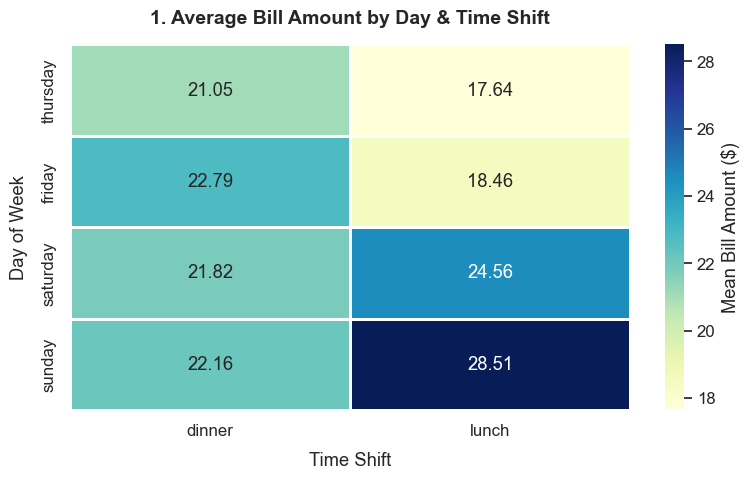

In [12]:
# average bill amount heatmap (day x time) -- this is mean bill amount per
# transaction, not summed revenue
plt.figure(figsize=(8, 5))
heatmap_data = df.pivot_table(
    index="day", columns="time", values="amount", aggfunc="mean", observed=False
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Mean Bill Amount ($)"},
    linewidths=1,
)
plt.title(
    "1. Average Bill Amount by Day & Time Shift",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Time Shift", labelpad=10)
plt.ylabel("Day of Week", labelpad=10)
plt.tight_layout()
plt.savefig(
    "report_charts/1_revenue_heatmap.png", dpi=300, bbox_inches="tight"
)
plt.show()

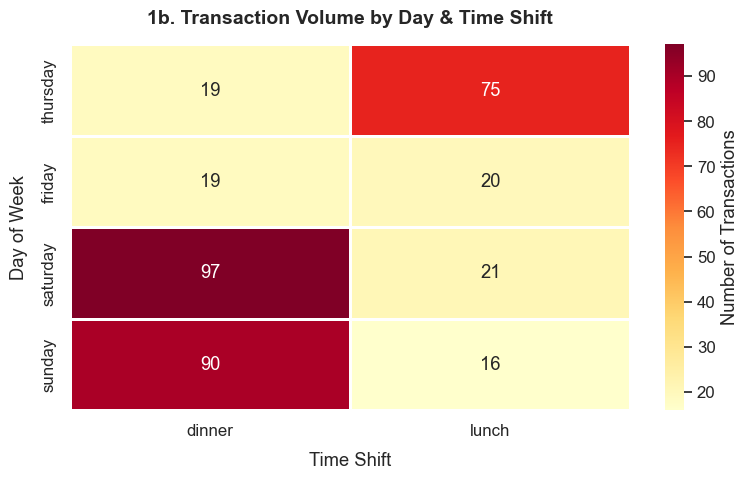

In [13]:
# day x time transaction-count heatmap -- this is what actually visualizes
# the HT5 finding (day and meal period are strongly associated, Cramer's V ~ 0.57);
# chart 1 above shows average bill amount, which is a separate, weaker finding (HT1)
plt.figure(figsize=(8, 5))
count_data = df.pivot_table(
    index="day", columns="time", values="amount", aggfunc="count", observed=False
)

sns.heatmap(
    count_data,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    cbar_kws={"label": "Number of Transactions"},
    linewidths=1,
)
plt.title(
    "1b. Transaction Volume by Day & Time Shift",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Time Shift", labelpad=10)
plt.ylabel("Day of Week", labelpad=10)
plt.tight_layout()
plt.savefig(
    "report_charts/1b_day_time_transaction_counts.png", dpi=300, bbox_inches="tight"
)
plt.show()

C:\Users\shash\AppData\Local\Temp\ipykernel_51732\1646064155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


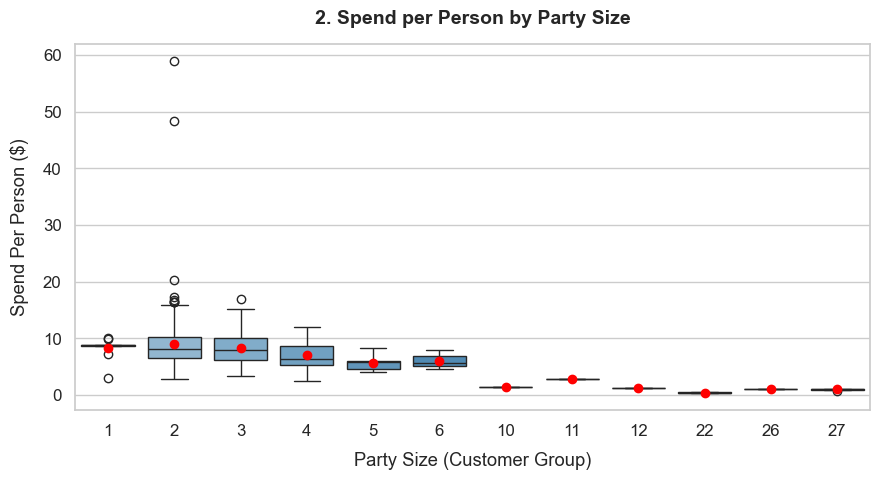

In [14]:
# table efficiency - spend per person by party size
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="partysize",
    y="spend_per_person",
    palette="Blues_d",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
plt.title(
    "2. Spend per Person by Party Size",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Party Size (Customer Group)", labelpad=10)
plt.ylabel("Spend Per Person ($)", labelpad=10)
plt.tight_layout()
plt.savefig(
    "report_charts/2_table_efficiency.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

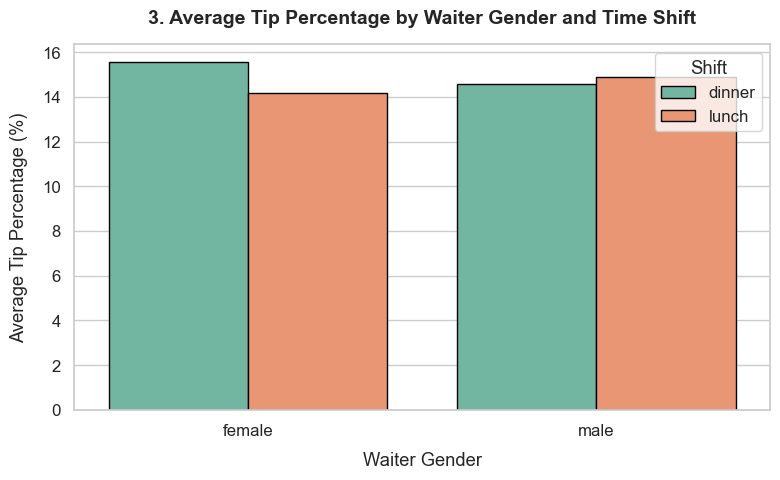

In [15]:
# tipping dynamics by gender & shift

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="gender",
    y="tip_pct",
    hue="time",
    palette="Set2",
    errorbar=None,
    edgecolor="black",
)
plt.title(
    "3. Average Tip Percentage by Waiter Gender and Time Shift",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Waiter Gender", labelpad=10)
plt.ylabel("Average Tip Percentage (%)", labelpad=10)
plt.legend(title="Shift", frameon=True)
plt.tight_layout()
plt.savefig(
    "report_charts/3_tipping_by_gender.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

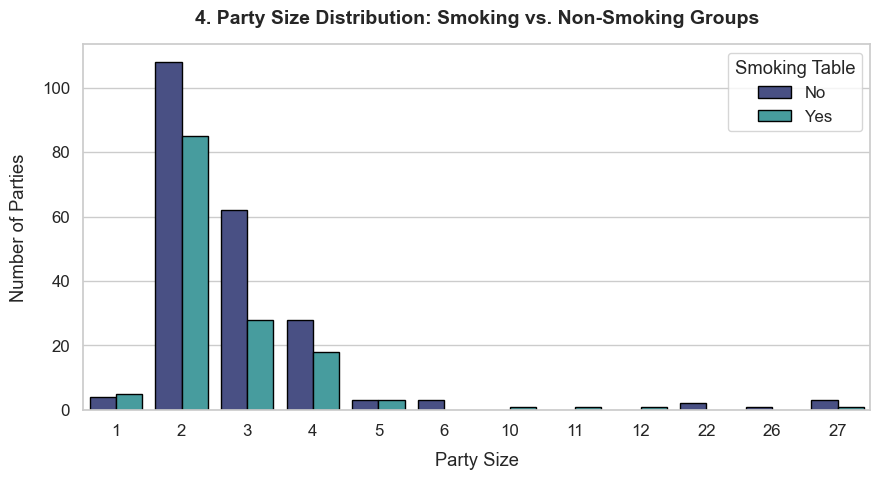

In [16]:
# group seating demographics (smoker vs non-smoker)
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df, x="partysize", hue="smoker", palette="mako", edgecolor="black"
)
plt.title(
    "4. Party Size Distribution: Smoking vs. Non-Smoking Groups",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Party Size", labelpad=10)
plt.ylabel("Number of Parties", labelpad=10)
plt.legend(title="Smoking Table", labels=["No", "Yes"], frameon=True)
plt.tight_layout()
plt.savefig(
    "report_charts/4_smoker_demographics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

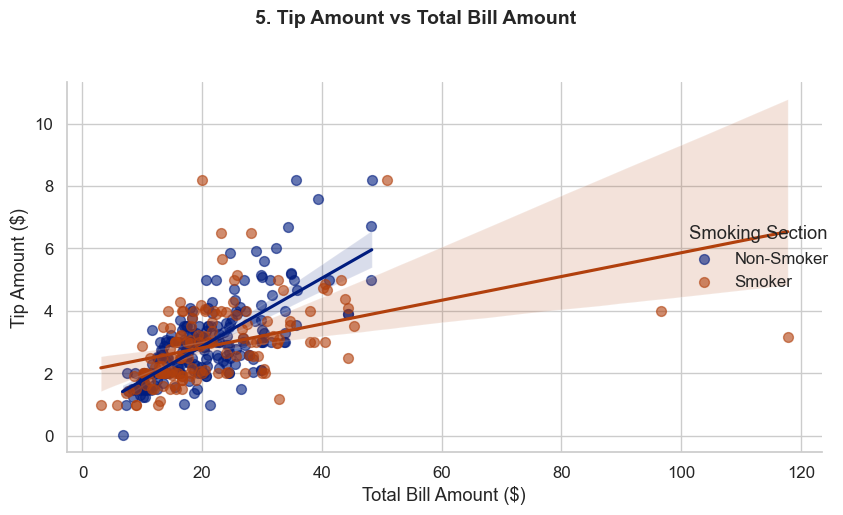

In [17]:
# linear spending-to-tipping scalability by smoking status
g = sns.lmplot(
    data=df,
    x="amount",
    y="tip",
    hue="smoker",
    palette="dark",
    height=5,
    aspect=1.5,
    scatter_kws={"alpha": 0.6, "s": 50},
)
g.fig.suptitle(
    "5. Tip Amount vs Total Bill Amount",
    fontsize=14,
    y=1.03,
    weight="bold",
)
g.set_axis_labels("Total Bill Amount ($)", "Tip Amount ($)")
g._legend.set_title("Smoking Section")
for t, l in zip(g._legend.texts, ["Non-Smoker", "Smoker"]):
    t.set_text(l)
plt.tight_layout()
plt.savefig(
    "report_charts/5_spending_vs_tip_lm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

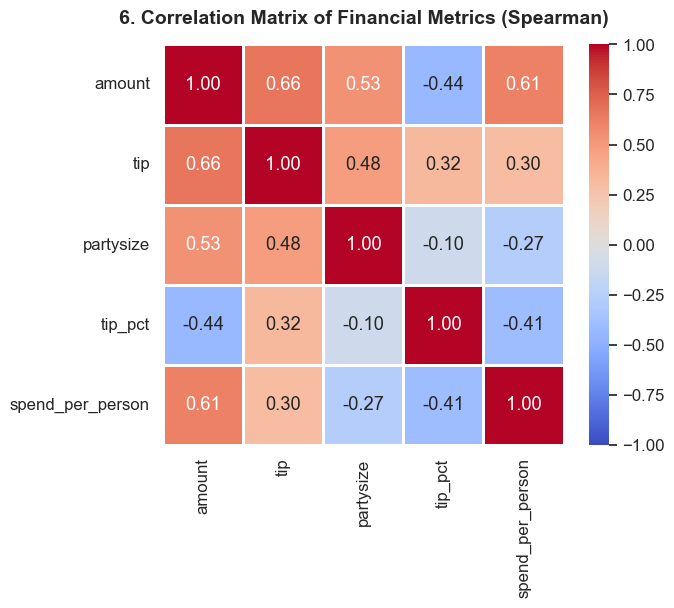

In [18]:
# financial and operational correlation heatmap
# Spearman, not Pearson -- amount/tip are right-skewed (see the normality
# checks above and the HT notebook), so Spearman is the consistent choice.
# note: tip_pct and spend_per_person are derived from amount/tip/partysize,
# so some of these correlations partly reflect shared arithmetic, not just
# an independent relationship.
plt.figure(figsize=(7, 6))
num_cols = ["amount", "tip", "partysize", "tip_pct", "spend_per_person"]
corr_matrix = df[num_cols].corr(method="spearman")

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
)
plt.title(
    "6. Correlation Matrix of Financial Metrics (Spearman)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.tight_layout()
plt.savefig(
    "report_charts/6_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()